In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq

# Data inladen
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
print("Dataset succesvol geladen.")

Dataset succesvol geladen.


markdown
# Analyse van Hartfalen: Klinische Statistiek en Signaalverwerking
**Auteur:** [Jouw Naam]  
**Expertise:** 1e graads Wiskunde & Natuurwetenschappen  

Dit project combineert statistische analyse van patiëntdata met Fourier-transformaties 
voor signaaloptimalisatie. We onderzoeken de correlatie tussen klinische parameters 
en passen digitale filters toe op gesimuleerde ECG-data

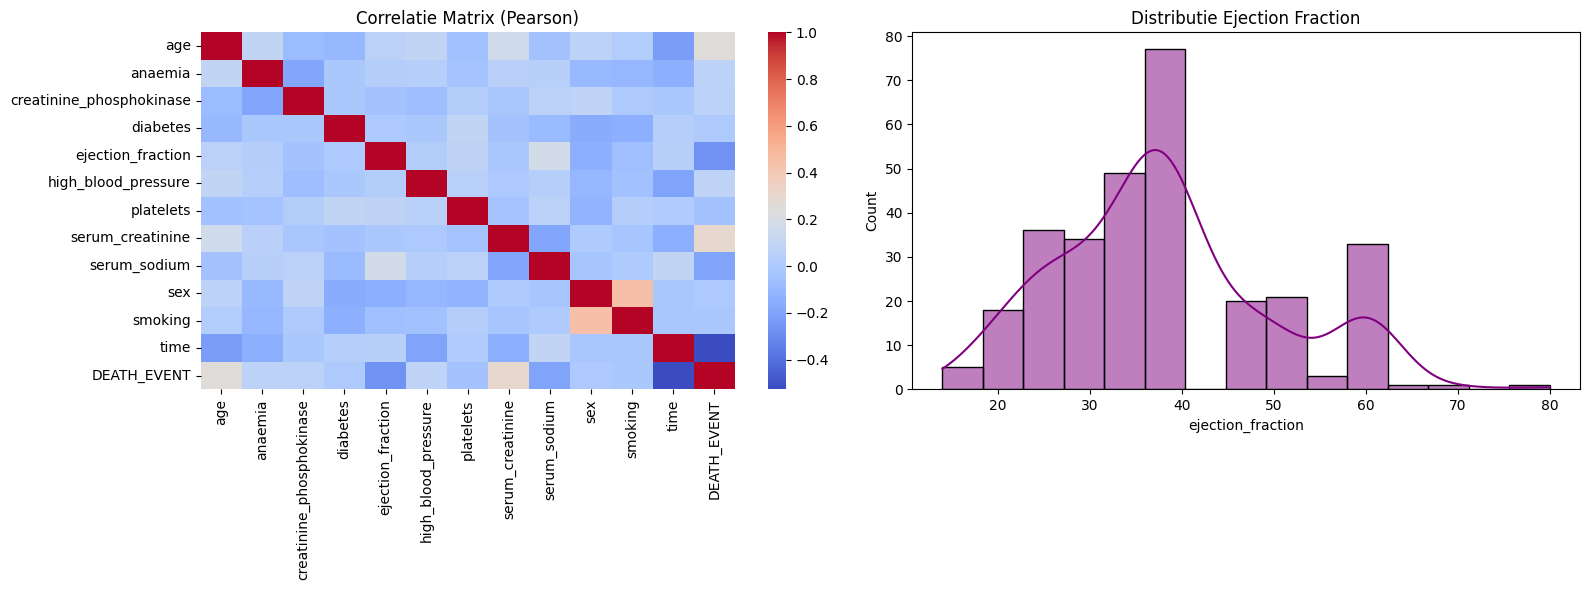

In [9]:
# We maken een figuur met twee subplots (Matrix en Grafiek)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Heatmap
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', ax=ax1)
ax1.set_title('Correlatie Matrix (Pearson)')

# Subplot 2: Histogram Hartfunctie
sns.histplot(df['ejection_fraction'], kde=True, color='purple', ax=ax2)
ax2.set_title('Distributie Ejection Fraction')

plt.tight_layout()
plt.show()

## 1. Statistische Correlatiematrix
We analyseren de onderlinge afhankelijkheid van parameters. De focus ligt op de 
Pearson-correlatie $\rho$ met betrekking tot de overlevingskans.

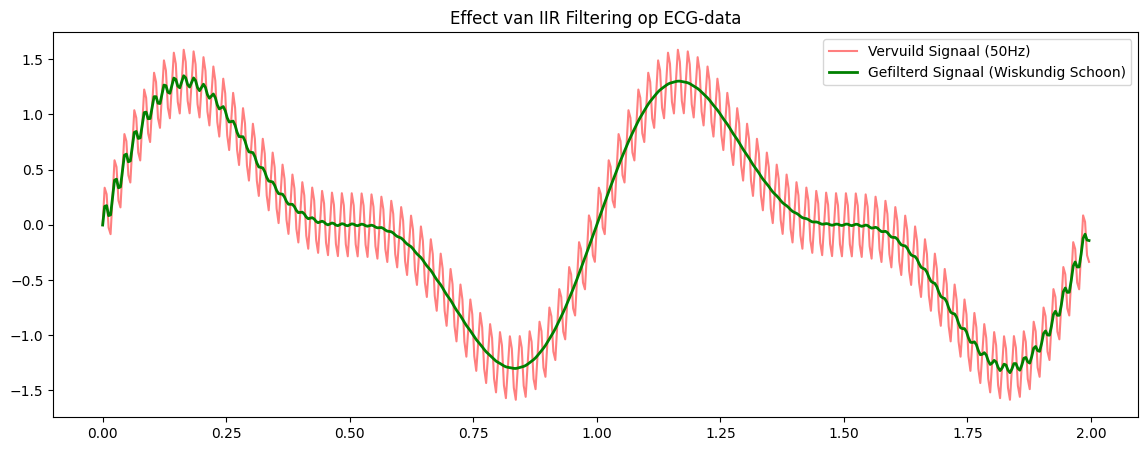

In [10]:
# 1. Signaal genereren
fs = 250
t = np.arange(0, 2, 1/fs)
ecg = np.sin(2*np.pi*1*t) + 0.5*np.sin(2*np.pi*2*t) + 0.3*np.sin(2*np.pi*50*t)

# 2. Notch Filter (50Hz verwijderen)
b, a = signal.iirnotch(50.0, 30.0, fs)
ecg_clean = signal.filtfilt(b, a, ecg)

# 3. Visualisatie van het effect
plt.figure(figsize=(14, 5))
plt.plot(t, ecg, label='Vervuild Signaal (50Hz)', alpha=0.5, color='red')
plt.plot(t, ecg_clean, label='Gefilterd Signaal (Wiskundig Schoon)', color='green', linewidth=2)
plt.title('Effect van IIR Filtering op ECG-data')
plt.legend()
plt.show()

## 2. Spectrale Analyse & Ruisonderdrukking
Fysiologische signalen bevatten vaak artefacten. Hieronder simuleren we een 
ECG-signaal met 50Hz netspanningsruis en elimineren we deze met een **IIR Notch Filter**.

### 2.2 Spectrale Validatie van het Notch Filter
Om te verifiëren of de interferentie van het lichtnet (50 Hz) daadwerkelijk is geëlimineerd, transformeren we het signaal van het tijdsdomein naar het frequentiedomein middels de **Discrete Fourier Transform (DFT)**:

$$X(k) = \sum_{n=0}^{N-1} x(n) \cdot e^{-i 2 \pi k n / N}$$

In de onderstaande spectrale analyse vergelijken we de amplituderespons vóór en na filtering. We verwachten een significante attenuatie bij $f = 50 \text{ Hz}$, terwijl de fysiologische componenten (doorgaans $< 40 \text{ Hz}$) ongewijzigd blijven. Dit waarborgt de signaalintegriteit voor verdere diagnostische interpretatie.

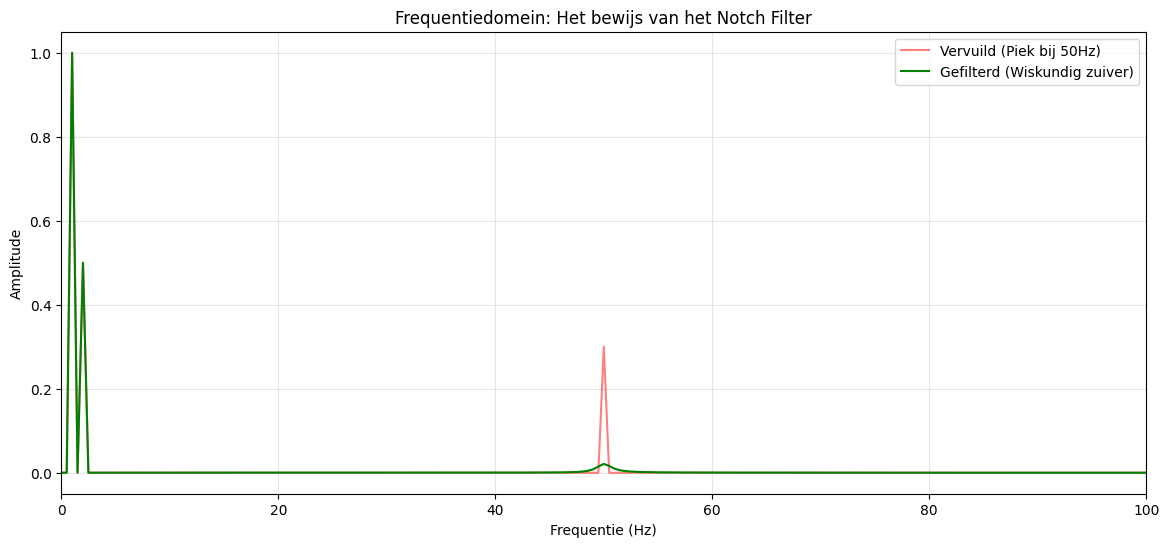

In [11]:
# 1. Bereken de Fourier Transformatie voor beide signalen
yf_dirty = fft(ecg)
yf_clean = fft(ecg_clean)
xf = fftfreq(len(t), 1/fs)[:len(t)//2]

# 2. Visualisatie van het Frequentiedomein
plt.figure(figsize=(14, 6))

# Grafiek met de ruis (Rood)
plt.plot(xf, 2.0/len(t) * np.abs(yf_dirty[0:len(t)//2]), color='red', alpha=0.5, label='Vervuild (Piek bij 50Hz)')

# Grafiek zonder de ruis (Groen)
plt.plot(xf, 2.0/len(t) * np.abs(yf_clean[0:len(t)//2]), color='green', label='Gefilterd (Wiskundig zuiver)')

plt.title('Frequentiedomein: Het bewijs van het Notch Filter')
plt.xlabel('Frequentie (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 100) # We focussen op 0-100 Hz voor de duidelijkheid
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()